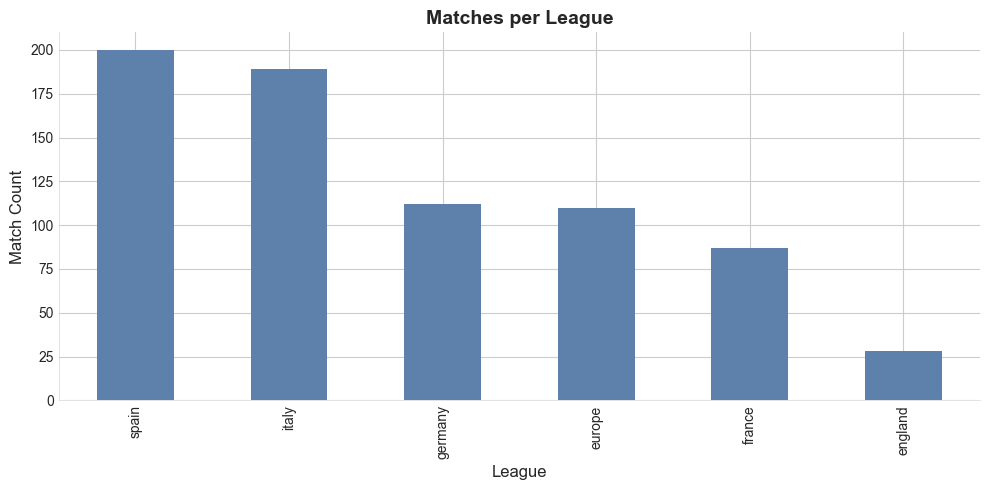

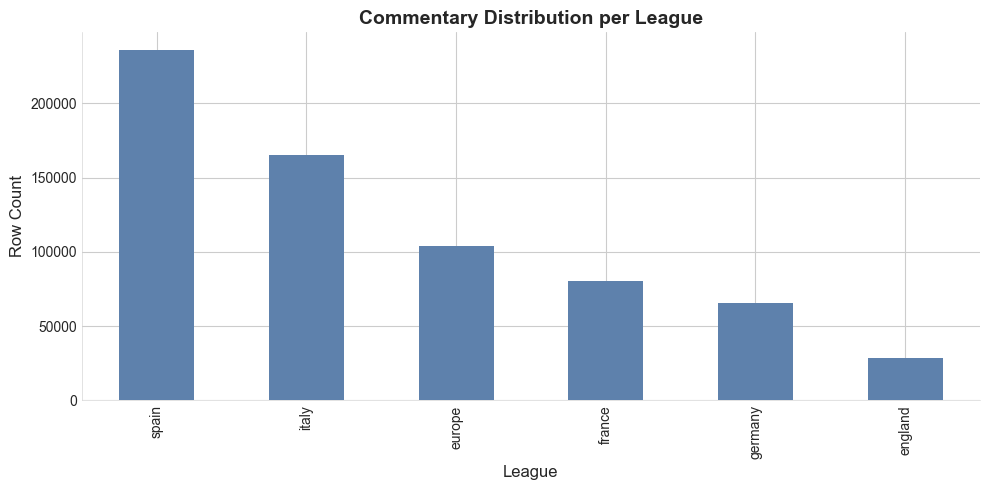

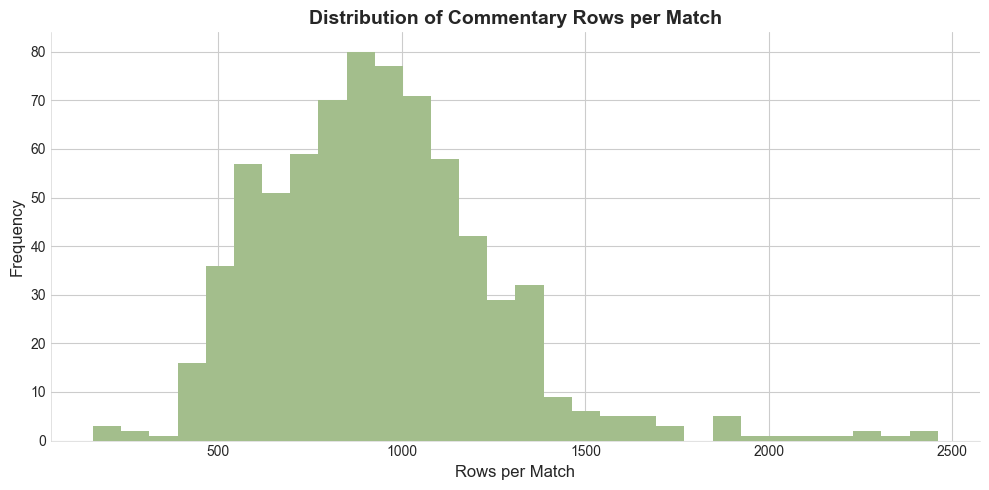

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Neutral minimalist style
plt.style.use("seaborn-v0_8-whitegrid")
neutral_colors = ["#4C566A", "#5E81AC", "#A3BE8C", "#88C0D0", "#B48EAD"]

# Create output directory
os.makedirs("eda_plots", exist_ok=True)

df = pd.read_csv("../data/football_commentary_labelled.csv")

# Regex extraction
df["league_extracted"] = df["game"].str.extract(r"^([a-zA-Z]+)")
df["match_extracted"] = df["game"].str.extract(r"^[a-zA-Z]+_(.*)$")


# -------------------------------------------------------
# Minimalist plot functions with PNG saving
# -------------------------------------------------------

def minimalist_bar(data, title, xlabel, ylabel, filename):
    plt.figure(figsize=(10, 5))
    ax = data.plot(
        kind="bar",
        color=neutral_colors[1],
        edgecolor="none"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    plt.tight_layout()
    plt.savefig(f"eda_plots/{filename}.png", dpi=600, bbox_inches="tight")
    plt.show()



def minimalist_hist(data, title, xlabel, ylabel, bins, filename):
    plt.figure(figsize=(10, 5))
    plt.hist(data, bins=bins, color=neutral_colors[2], edgecolor="none")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["bottom"].set_linewidth(0.4)

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    plt.tight_layout()
    plt.savefig(f"eda_plots/{filename}.png", dpi=600, bbox_inches="tight")
    plt.show()


# -------------------------------------------------------
# Matches per league
# -------------------------------------------------------
matches_per_league = (
    df.groupby("league_extracted")["match_extracted"]
    .nunique()
    .sort_values(ascending=False)
)

minimalist_bar(
    matches_per_league,
    title="Matches per League",
    xlabel="League",
    ylabel="Match Count",
    filename="matches_per_league"
)

# -------------------------------------------------------
# Commentary rows per league
# -------------------------------------------------------
league_counts = df["league_extracted"].value_counts()

minimalist_bar(
    league_counts,
    title="Commentary Distribution per League",
    xlabel="League",
    ylabel="Row Count",
    filename="commentary_per_league"
)

# -------------------------------------------------------
# Commentary per match distribution
# -------------------------------------------------------
match_counts = df["match_extracted"].value_counts()

minimalist_hist(
    match_counts,
    title="Distribution of Commentary Rows per Match",
    xlabel="Rows per Match",
    ylabel="Frequency",
    bins=30,
    filename="commentary_rows_per_match_distribution"
)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("../data/football_commentary_labelled.csv")

# ------------------------------
# Extract season (folder 2)
# ------------------------------
df["season"] = df["game"].str.extract(r"^[^/]+/([^/]+)/")

# ------------------------------
# Extract full date from segment 3
# ------------------------------
df["full_date"] = df["game"].str.extract(r"/(\d{4}-\d{2}-\d{2}) -")

# Extract year
df["year"] = df["full_date"].str.extract(r"^(\d{4})")

# Extract month
df["month"] = df["full_date"].str.extract(r"^\d{4}-(\d{2})")

# ------------------------------
# Extract time
# ------------------------------
df["kickoff_time"] = df["game"].str.extract(r"- (\d{2}-\d{2}) ")

# ------------------------------
# Extract teams and score
# ------------------------------
team_score_pattern = r"\d{2}-\d{2} ([A-Za-z0-9 .]+) (\d+) - (\d+) ([A-Za-z0-9 .]+)/"

df[["home_team", "home_goals", "away_goals", "away_team"]] = df["game"].str.extract(team_score_pattern)

# Convert goals to integers
df["home_goals"] = pd.to_numeric(df["home_goals"], errors="coerce")
df["away_goals"] = pd.to_numeric(df["away_goals"], errors="coerce")

# ------------------------------
# Extract commentary index
# ------------------------------
df["commentary_index"] = df["game"].str.extract(r"/(\d+)$").astype(int)


#### Years Available in the Commentary Dataset


Years present in dataset:
year
2014      9638
2015    167376
2016    253081
2017    230075
2019     11804
2020      7764
Name: count, dtype: int64


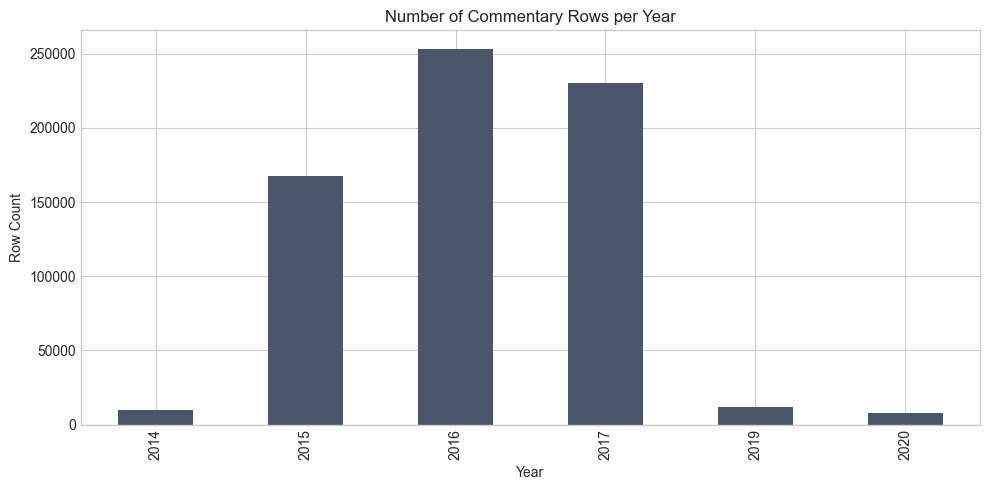

In [11]:
year_counts = df["year"].value_counts().sort_index()

print("\nYears present in dataset:")
print(year_counts)

plt.figure(figsize=(10, 5))
year_counts.plot(kind="bar", color="#4C566A", edgecolor="none")
plt.title("Number of Commentary Rows per Year")
plt.xlabel("Year")
plt.ylabel("Row Count")
plt.tight_layout()
plt.savefig("eda_plots/commentary_rows_per_year.png", dpi=600, bbox_inches="tight")
plt.show()


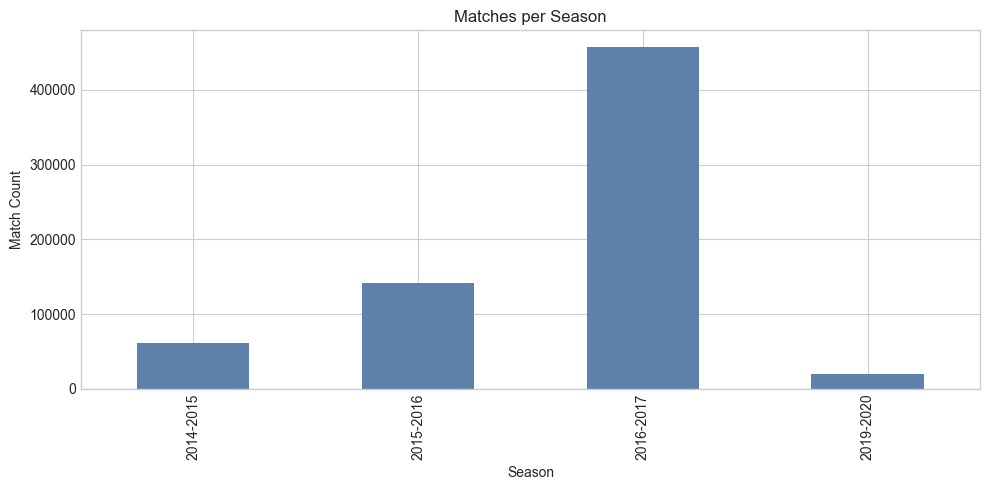

In [12]:
season_counts = df["season"].value_counts().sort_index()

plt.figure(figsize=(10,5))
season_counts.plot(kind="bar", color="#5E81AC", edgecolor="none")
plt.title("Matches per Season")
plt.xlabel("Season")
plt.ylabel("Match Count")
plt.tight_layout()
plt.savefig("eda_plots/matches_per_season.png", dpi=600, bbox_inches="tight")
plt.show()


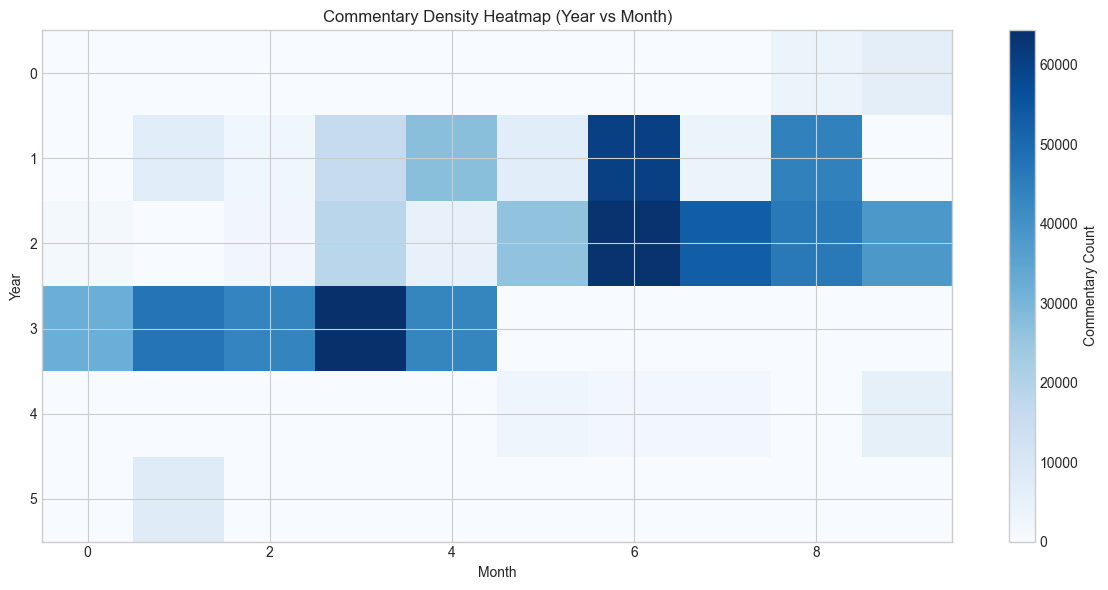

In [13]:
df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)

pivot = df.pivot_table(index="year", columns="month", values="game", aggfunc="count").fillna(0)

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto", cmap="Blues")
plt.colorbar(label="Commentary Count")
plt.title("Commentary Density Heatmap (Year vs Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig("eda_plots/commentary_heatmap_year_month.png", dpi=600, bbox_inches="tight")
plt.show()


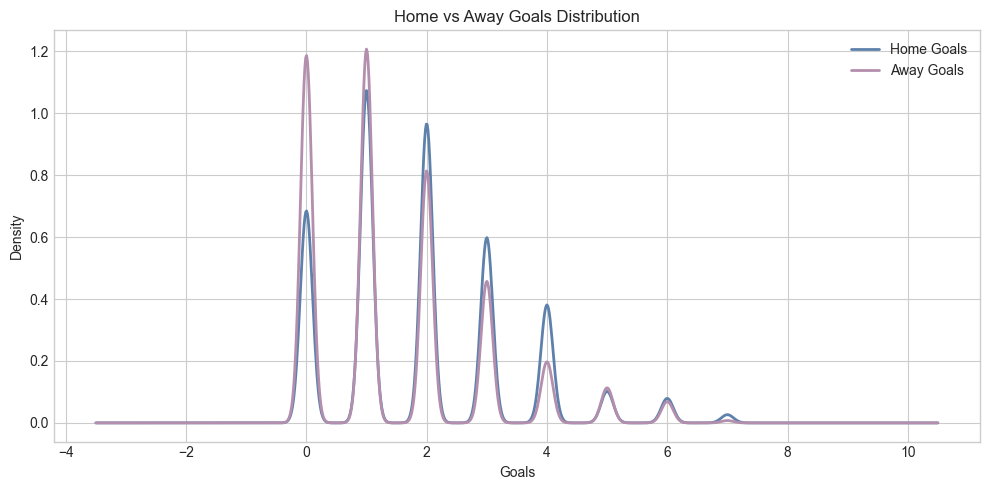

In [15]:
plt.figure(figsize=(10,5))
df["home_goals"].plot.kde(linewidth=2, color="#5E81AC", label="Home Goals")
df["away_goals"].plot.kde(linewidth=2, color="#B48EAD", label="Away Goals")
plt.title("Home vs Away Goals Distribution")
plt.xlabel("Goals")
plt.legend()
plt.tight_layout()
plt.savefig("eda_plots/home_away_goals_kde.png", dpi=600, bbox_inches="tight")
plt.show()


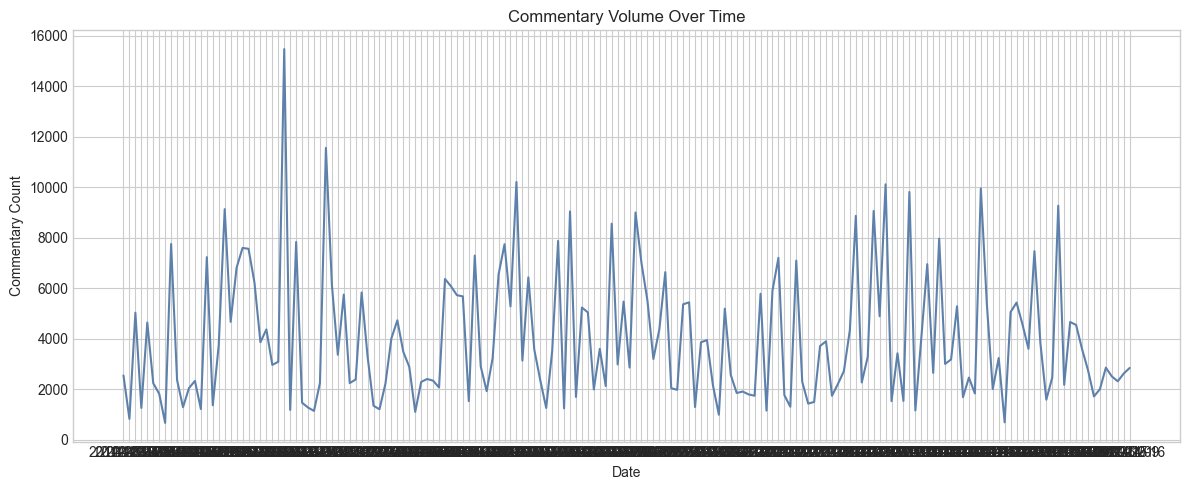

In [16]:
df_by_date = df.groupby("full_date").size().sort_index()

plt.figure(figsize=(12,5))
plt.plot(df_by_date.index, df_by_date.values, color="#5E81AC")
plt.title("Commentary Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Commentary Count")
plt.tight_layout()
plt.savefig("eda_plots/commentary_over_time.png", dpi=600, bbox_inches="tight")
plt.show()


In [ ]:
import seaborn as sns

score_matrix = pd.crosstab(df["home_goals"], df["away_goals"])

plt.figure(figsize=(8,6))
sns.heatmap(score_matrix, cmap="Blues", annot=True, fmt="d")
plt.title("Scoreline Frequency Matrix")
plt.xlabel("Away Goals")
plt.ylabel("Home Goals")
plt.tight_layout()
plt.savefig("eda_plots/scoreline_matrix.png", dpi=600, bbox_inches="tight")
plt.show()
